In [226]:

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import time
from tqdm.auto import tqdm
from dataclasses import dataclass, field, asdict
from typing import List
import json
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib
from sklearn.metrics import balanced_accuracy_score

matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['font.family'] = 'Arial'

# ---------------------------------------------------------
# [1] Config: 전략적 가중치 및 페이즈 설정 추가
# ---------------------------------------------------------
@dataclass
class VAEConfig:
    input_dim: int
    cond_dim: int
    num_classes: int
    hc_label_idx: int 
    
    latent_dim: int = 32
    hidden_dims: List[int] = field(default_factory=lambda: [512, 256])
    skeleton_hidden_dim: int = 16 
    
    dropout: float = 0.1
    lambda_rec: float = 1.0
    lambda_kl: float = 0.5
    lambda_class: float = 5.0
    
    # Anchor & Bridge Weights
    lambda_soft_anchor: float = 1.0  # HC mu -> 0
    lambda_res_anchor: float = 1.0   # HC x_res -> 0
    lambda_hsic: float = 1.0         # HC 전용 HSIC 가중치
    
    # Training settings
    warmup_epochs: int = 20           # Skeleton 선행 학습 기간
    epochs: int = 100
    lr: float = 1e-4
    weight_decay: float = 1e-4
    batch_size: int = 128
    device: str = "cuda" if torch.cuda.is_available() else "cpu"

    def save(self, path: str):
        with open(path, 'w', encoding='utf-8') as f:
            json.dump(asdict(self), f, indent=4, ensure_ascii=False)
        print(f"Config saved to {path}")

# ---------------------------------------------------------
# [2] HSIC & Kernel (기존 유지)
# ---------------------------------------------------------
def compute_kernel(x, y):
    x_size, y_size, dim = x.size(0), y.size(0), x.size(1)
    kernel_input = (x.unsqueeze(1) - y.unsqueeze(0)).pow(2).mean(2) / float(dim)
    sigma = torch.median(kernel_input).detach()
    if sigma == 0: sigma = torch.tensor(1.0, device=x.device)
    return torch.exp(-kernel_input / (2 * sigma + 1e-8))

def compute_hsic(z, c):
    m = z.size(0)
    if m <= 8: return torch.tensor(0.0, device=z.device)
    K, L = compute_kernel(z, z), compute_kernel(c, c)
    K_centered = K - K.mean(dim=0, keepdim=True)
    L_centered = L - L.mean(dim=0, keepdim=True)
    return torch.sum(K_centered * L_centered) / ((m - 1) ** 2)

class cfRNA_VAE(nn.Module):
    def __init__(self, config: VAEConfig):
        super().__init__()
        self.config = config
        self.skeleton_net = nn.Sequential(
            nn.Linear(config.cond_dim, config.skeleton_hidden_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(config.skeleton_hidden_dim, config.input_dim)
        )
        self.encoder = nn.Sequential(
            nn.Linear(config.input_dim + config.cond_dim, config.hidden_dims[0]),
            nn.BatchNorm1d(config.hidden_dims[0]),
            nn.LeakyReLU(0.2),
            nn.Linear(config.hidden_dims[0], config.hidden_dims[1]),
            nn.BatchNorm1d(config.hidden_dims[1]),
            nn.LeakyReLU(0.2)
        )
        self.fc_mu = nn.Linear(config.hidden_dims[1], config.latent_dim)
        self.fc_logvar = nn.Linear(config.hidden_dims[1], config.latent_dim)
        self.residual_net = nn.Sequential(
            nn.Linear(config.latent_dim, config.hidden_dims[1]),
            nn.ReLU(),
            nn.Linear(config.hidden_dims[1], config.hidden_dims[0]),
            nn.ReLU(),
            nn.Linear(config.hidden_dims[0], config.input_dim)
        )
        self.classifier = nn.Linear(config.latent_dim, config.num_classes)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + torch.randn_like(std) * std

    def forward(self, x, c):
        x_base = self.skeleton_net(c)
        h = self.encoder(torch.cat([x - x_base, c], dim=1))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        z = self.reparameterize(mu, logvar)
        x_res = self.residual_net(z)
        x_hat = x_base + x_res
        y_pred = self.classifier(z)
        return x_hat, mu, logvar, y_pred, x_base, x_res

# ---------------------------------------------------------
# [4] Strategic Loss: Phase-aware & Selective HSIC
# ---------------------------------------------------------
def compute_loss(batch, model_out, config: VAEConfig, phase="full"):
    x_hat, mu, logvar, y_pred, x_base, x_res = model_out
    x, c, y = batch['x'], batch['c'], batch['y']
    
    # 1. Reconstruction Loss (항상 포함)
    l_rec = F.mse_loss(x_hat, x)
    
    # Warmup 단계: Skeleton만 학습하도록 나머지 Loss 차단
    if phase == "warmup":
        return l_rec, (l_rec, 0., 0., 0., 0., 0.)

    # 2. Base Bio-signal Losses
    l_kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
    l_ce = F.cross_entropy(y_pred, y)
    
    # 3. HC-as-a-Bridge Strategy (Selective Constraints)
    is_hc = (y == config.hc_label_idx)
    l_anc_mu = torch.tensor(0.0, device=config.device)
    l_anc_res = torch.tensor(0.0, device=config.device)
    l_hsic = torch.tensor(0.0, device=config.device)

    if is_hc.any():
        l_anc_mu = torch.mean(mu[is_hc].pow(2))
        l_anc_res = torch.mean(x_res[is_hc].pow(2))
        l_hsic = compute_hsic(mu[is_hc], c[is_hc])

    total = (l_rec * config.lambda_rec) + \
            (l_kl * config.lambda_kl) + \
            (l_ce * config.lambda_class) + \
            (l_anc_mu * config.lambda_soft_anchor) + \
            (l_anc_res * config.lambda_res_anchor) + \
            (l_hsic * config.lambda_hsic)
            
    return total, (l_rec, l_kl, l_ce, l_anc_mu, l_anc_res, l_hsic)

# ---------------------------------------------------------
# [5] Trainer: Skeleton Priority (Phase Management)
# ---------------------------------------------------------
class VAETrainer:
    def __init__(self, model: cfRNA_VAE, config: VAEConfig):
        self.model = model.to(config.device)
        self.config = config
        self.optimizer = torch.optim.AdamW(model.parameters(), lr=config.lr, weight_decay=config.weight_decay)
        self.scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(self.optimizer, mode='max', factor=0.5, patience=5)
        self.history = []

    def run_epoch(self, loader, epoch, is_train=True, phase="full"):
        self.model.train() if is_train else self.model.eval()
        metrics = {k: 0.0 for k in ['total', 'rec', 'kl', 'ce', 'anc_mu', 'anc_res', 'hsic']}
        all_preds, all_labels = [], []
        total_samples = 0
        
        for batch in tqdm(loader, desc=f"{phase.upper()} {epoch}", leave=False):
            batch = {k: v.to(self.config.device) for k, v in batch.items()}
            batch_size = batch['x'].size(0)
            
            with torch.set_grad_enabled(is_train):
                model_out = self.model(batch['x'], batch['c'])
                loss, losses = compute_loss(batch, model_out, self.config, phase=phase)
                
                if is_train:
                    self.optimizer.zero_grad()
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), 5.0)
                    self.optimizer.step()

            # Logging (losses 언패킹 시 warm-up 대응 필요)
            l_r, l_k, l_c, l_am, l_ar, l_h = [l.item() if torch.is_tensor(l) else l for l in losses]
            metrics['total'] += loss.item() * batch_size
            metrics['rec'] += l_r * batch_size
            metrics['kl'] += l_k * batch_size
            metrics['ce'] += l_c * batch_size
            metrics['anc_mu'] += l_am * batch_size
            metrics['anc_res'] += l_ar * batch_size
            metrics['hsic'] += l_h * batch_size
            
            all_preds.append(model_out[3].argmax(1).cpu().numpy())
            all_labels.append(batch['y'].cpu().numpy())
            total_samples += batch_size
            
        y_true = np.concatenate(all_labels)
        y_pred = np.concatenate(all_preds)
        b_acc = balanced_accuracy_score(y_true, y_pred) if phase == "full" else 0.0
        
        avg_metrics = {k: v / total_samples for k, v in metrics.items()}
        avg_metrics['b_acc'] = b_acc
        return avg_metrics

    def fit(self, train_loader, val_loader):
        print(f"🔥 Phase 1: Skeleton Warmup ({self.config.warmup_epochs} epochs)")

        for name, param in self.model.named_parameters():
            if "skeleton" not in name: param.requires_grad = False

        for epoch in range(1, self.config.warmup_epochs + 1):
            t_m = self.run_epoch(train_loader, epoch, is_train=True, phase="warmup")
            print(f"Warmup {epoch} | Rec: {t_m['rec']:.4f}")

        print(f"🚀 Phase 2: Full Training with HC-Bridge ({self.config.epochs} epochs)")
        for param in self.model.parameters(): param.requires_grad = True

        for epoch in range(1, self.config.epochs + 1):
            t_m = self.run_epoch(train_loader, epoch, is_train=True, phase="full")
            v_m = self.run_epoch(val_loader, epoch, is_train=False, phase="full")
            
            self.scheduler.step(v_m['b_acc'])
            print(f"[{epoch}/{self.config.epochs}] V-BAcc: {v_m['b_acc']:.4f} | Rec: {v_m['rec']:.4f} | ResAnc: {v_m['anc_res']:.4f} | HC-HSIC: {v_m['hsic']:.4f}")
            self.history.append({'epoch': epoch, 'train': t_m, 'val': v_m})
            
    @torch.no_grad()
    def get_outputs(self, loader):
        self.model.eval()
        results = {'z': [], 'x_hat': [], 'x_base': [], 'x_res': [], 'y': [], 'c': [], 'indices': []}
        
        for batch in tqdm(loader, desc="Extracting"):
            x, c = batch['x'].to(self.config.device), batch['c'].to(self.config.device)
            x_hat, mu, _, _, x_base, x_res = self.model(x, c)
            
            results['z'].append(mu.cpu().numpy())
            results['x_hat'].append(x_hat.cpu().numpy())
            results['x_base'].append(x_base.cpu().numpy())
            results['x_res'].append(x_res.cpu().numpy())
            results['y'].append(batch['y'].cpu().numpy())
            results['c'].append(batch['c'].cpu().numpy())
            results['indices'].append(batch['idx'].cpu().numpy()) # idx 추가됨

        final_res = {}
        for k, v in results.items():
            if k in ['z', 'x_hat', 'x_base', 'x_res', 'c']: 
                final_res[k] = np.vstack(v)
            else:
                final_res[k] = np.concatenate(v)
                
        return final_res

    def get_ann_data(self, loader, class_names=None):
        res = self.get_outputs(loader)
        adata = sc.AnnData(X=res['x_res']) 
        adata.obs['Phenotype'] = pd.Categorical([class_names[int(i)] for i in res['y']]) if class_names else res['y'].astype(str)
        if res['c'].ndim > 1: adata.obs['BatchID'] = res['c'].argmax(axis=1).astype(str)
        adata.obsm['X_vae'] = res['z']
        adata.layers['skeleton'], adata.layers['residual'] = res['x_base'], res['x_res']
        return adata
    
class CfRNADataset(Dataset):
    def __init__(self, expression, condition, labels, split_groups=None):
        self.x = torch.tensor(expression.values if hasattr(expression, 'values') else expression, dtype=torch.float32)
        self.c = torch.tensor(condition.values if hasattr(condition, 'values') else condition, dtype=torch.float32)
        self.y = torch.tensor(labels.values if hasattr(labels, 'values') else labels, dtype=torch.long)
        self.groups = np.array(split_groups) if split_groups is not None else None
        self.num_classes = len(torch.unique(self.y))
        self.input_dim = self.x.shape[1]
        self.cond_dim = self.c.shape[1]

    def __len__(self):
        return self.x.shape[0]

    def __getitem__(self, idx):
        return {'x': self.x[idx], 'c': self.c[idx], 'y': self.y[idx], 'idx': idx}

In [227]:
import scanpy as sc

adata = sc.read_h5ad("OpenAccess_Filtered_Heuristic.h5ad")
x_data = adata.layers['Standard_LogCPM']
print(x_data.shape) 
bias_metrics = ['gc_bias_score', 'len_bias_score', 'platelet_score', 'log1p_total_counts', 'NG80', 'NP80', 'NP80_NG80_ratio','FSR']
batch_cols = ['BioProject','tissue','Instrument','LibrarySelection']
bias_df = adata.obs[bias_metrics].copy()
print(bias_df.shape) 
batch_df = adata.obs[batch_cols].copy()
print(batch_df.shape) 
label_df = adata.obs['Phenotype'].copy()
print(label_df.shape) 

del(adata)

(2073, 3394)
(2073, 8)
(2073, 4)
(2073,)


In [228]:
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader, WeightedRandomSampler
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
def prepare_granular_loaders(
    expr_np, batch_df, bias_df, label_df, batch_size=128, resampling=True, resample_type='label'
):
    # 1. Stratification 및 Granular Key 생성
    granular_id = batch_df.apply(lambda x: "_".join(x.astype(str)), axis=1)
    stratify_key = label_df.astype(str) + "||" + granular_id.astype(str)
    
    cat_labels = pd.Categorical(label_df)
    y_encoded = cat_labels.codes
    num_classes = len(cat_labels.categories)
    
    # Stratified Split
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    try:
        train_idx, val_idx = next(sss.split(expr_np, stratify_key))
    except ValueError:
        print("⚠️ 일부 조합의 샘플이 부족하여 Label 기준으로만 Stratify를 진행합니다.")
        train_idx, val_idx = next(sss.split(expr_np, y_encoded))

    # 2. 데이터 분할
    x_train, x_val = expr_np[train_idx], expr_np[val_idx]
    y_train, y_val = y_encoded[train_idx], y_encoded[val_idx]

    # 3. Feature Scaling (Bias/Continuous)
    scaler = StandardScaler()
    bias_train_scaled = scaler.fit_transform(bias_df.iloc[train_idx])
    bias_val_scaled = scaler.transform(bias_df.iloc[val_idx])

    # 4. One-hot Encoding (Batch/Categorical)
    batch_dummy = pd.get_dummies(batch_df, columns=batch_df.columns, dtype=float)
    
    # 5. Condition 벡터 결합
    cond_train = np.hstack([bias_train_scaled, batch_dummy.iloc[train_idx].values])
    cond_val = np.hstack([bias_val_scaled, batch_dummy.iloc[val_idx].values])
    # 6. Metadata 저장
    meta_train_label = pd.DataFrame({'Phenotype': label_df.iloc[train_idx].values})
    meta_val_label = pd.DataFrame({'Phenotype': label_df.iloc[val_idx].values})
    meta_train_batch = batch_df.iloc[train_idx].reset_index(drop=True)
    meta_val_batch = batch_df.iloc[val_idx].reset_index(drop=True)
    # 6. Resampling 로직 적용
    sampler = None
    if resampling:
        if resample_type == 'granular':
            resample_keys = stratify_key.iloc[train_idx].values
        else:
            resample_keys = y_train
            
        u_keys, u_counts = np.unique(resample_keys, return_counts=True)
        weight_map = {k: 1./c for k, c in zip(u_keys, u_counts)}
        samples_weight = torch.tensor([weight_map[k] for k in resample_keys], dtype=torch.double)
        
        sampler = WeightedRandomSampler(samples_weight, len(samples_weight), replacement=True)

    # 7. Dataset 및 Loader 생성
    train_ds = CfRNADataset(x_train, cond_train, y_train)
    val_ds = CfRNADataset(x_val, cond_val, y_val)

    train_ds.obs_info = pd.concat([meta_train_label, meta_train_batch], axis=1)
    val_ds.obs_info = pd.concat([meta_val_label, meta_val_batch], axis=1)

    train_loader = DataLoader(
        train_ds, 
        batch_size=batch_size, 
        sampler=sampler, 
        shuffle=(sampler is None), 
        num_workers=0, 
        pin_memory=True
    )
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, num_classes

In [229]:
# batch_cols에 정의된 모든 정보를 '하나의 배치 단위'로 인식하여 분할합니다.
train_loader, val_loader, n_classes = prepare_granular_loaders(
    expr_np=x_data,
    batch_df=batch_df, # 'BioProject', 'Instrument', 'LibrarySelection' 등
    bias_df=bias_df,
    label_df=label_df,
    batch_size=128
)
sample_batch = next(iter(train_loader))
input_dim = sample_batch['x'].shape[1]
cond_dim = sample_batch['c'].shape[1]

In [230]:
cat_labels = pd.Categorical(label_df)
cat_labels = cat_labels.categories.tolist()
hc_label_idx = cat_labels.index('Healthy Control')

In [231]:
# 1. Config 설정 (전략적 가중치 반영)
config = VAEConfig(
    input_dim=input_dim,
    cond_dim=cond_dim,
    num_classes=n_classes,
    hc_label_idx=hc_label_idx,
    hidden_dims=[512, 256],
    skeleton_hidden_dim=8,    
    latent_dim=16,           
    # 학습 파라미터
    warmup_epochs=50,        
    epochs=100,               
    lr=1e-3,
    batch_size=128,
    lambda_rec=1.0,           # 재구성 손실 (기본값 유지)
    lambda_kl=1.0,            # Latent 정규화 (과적합 방지 위해 0.5 -> 1.0 상향)
    lambda_class=1.0,        # 분류 성능 (B-Acc 개선을 위해 상향)
    lambda_soft_anchor=1.0,  # HC mu -> 0 (강하게 결속)
    lambda_res_anchor=1.0,   # HC x_res -> 0 (HC의 변동을 Skeleton으로 몰아넣음)
    lambda_hsic=1.0         # HC 내부의 배치 독립성 (가장 강력하게 부여)
)

# 2. 모델 및 트레이너 초기화
model = cfRNA_VAE(config)
trainer = VAETrainer(model, config)

# 3. 전략적 학습 실행 (Phase 1 & Phase 2 자동 수행)
# fit 메서드 내부에서 skeleton warmup 후 full training으로 전환됩니다.
trainer.fit(train_loader, val_loader) 

# 4. 결과 저장 (경로 유지)
save_dir = "/project/cfRNA_Disentaglement/Data_For_Modeling/TestModels/v2/"
import os
os.makedirs(save_dir, exist_ok=True) # 경로가 없을 경우 생성

config.save(os.path.join(save_dir, "cfRNA_VAE_v2_config.json"))
torch.save(model.state_dict(), os.path.join(save_dir, "cfRNA_VAE_v2_model.pt"))

print(f"🎉 전략적 학습 완료 및 모델 저장 성공! (Device: {config.device})")

🔥 Phase 1: Skeleton Warmup (50 epochs)


WARMUP 1:   0%|          | 0/13 [00:00<?, ?it/s]

Warmup 1 | Rec: 5.2494


WARMUP 2:   0%|          | 0/13 [00:00<?, ?it/s]

Warmup 2 | Rec: 5.0485


...

FULL 99:   0%|          | 0/4 [00:00<?, ?it/s]

[99/100] V-BAcc: 0.0516 | Rec: 0.8700 | ResAnc: 0.0004 | HC-HSIC: 0.0233


FULL 100:   0%|          | 0/13 [00:00<?, ?it/s]

FULL 100:   0%|          | 0/4 [00:00<?, ?it/s]

[100/100] V-BAcc: 0.0297 | Rec: 0.8699 | ResAnc: 0.0005 | HC-HSIC: 0.0235
Config saved to /project/cfRNA_Disentaglement/Data_For_Modeling/TestModels/v2/cfRNA_VAE_v2_config.json
🎉 전략적 학습 완료 및 모델 저장 성공! (Device: cuda)


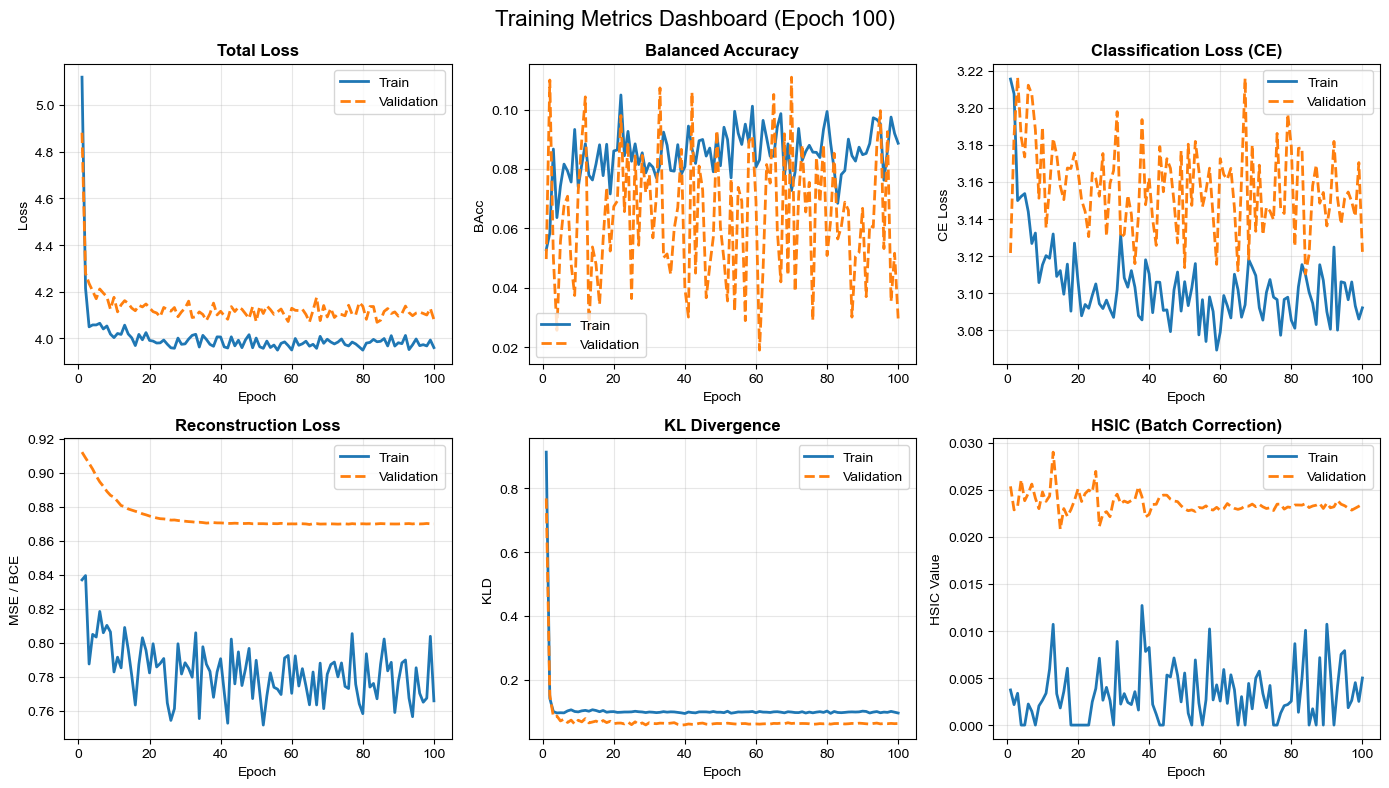

In [232]:
def plot_training_history_2x3(history):
    records = []
    for entry in history:
        row = {'epoch': entry['epoch']}
        # Train Metrics
        for k, v in entry['train'].items():
            row[f'train_{k}'] = v
        # Val Metrics
        if 'val' in entry and entry['val']:
            for k, v in entry['val'].items():
                row[f'val_{k}'] = v
        records.append(row)
        
    df = pd.DataFrame(records)
    epochs = df['epoch']
    
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    plt.subplots_adjust(hspace=0.3, wspace=0.25)
    
    def plot_metric(ax, metric_key, title, ylabel):
        # Train Plot
        train_col = f'train_{metric_key}'
        if train_col in df.columns:
            ax.plot(epochs, df[train_col], label='Train', color='#1f77b4', linewidth=2)
            
        # Val Plot (데이터가 있을 경우만)
        val_col = f'val_{metric_key}'
        if val_col in df.columns:
            ax.plot(epochs, df[val_col], label='Validation', color='#ff7f0e', linestyle='--', linewidth=2)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_ylabel(ylabel)
        ax.legend(loc='best')
        ax.grid(True, alpha=0.3)

    plot_metric(axes[0, 0], 'total', 'Total Loss', 'Loss')
    plot_metric(axes[0, 1], 'b_acc', 'Balanced Accuracy', 'BAcc')
    plot_metric(axes[0, 2], 'ce', 'Classification Loss (CE)', 'CE Loss')
    plot_metric(axes[1, 0], 'rec', 'Reconstruction Loss', 'MSE / BCE')
    plot_metric(axes[1, 1], 'kl', 'KL Divergence', 'KLD')
    plot_metric(axes[1, 2], 'hsic', 'HSIC (Batch Correction)', 'HSIC Value')

    last_epoch = df['epoch'].iloc[-1]
    fig.suptitle(f'Training Metrics Dashboard (Epoch {last_epoch})', fontsize=16)
    plt.tight_layout()
    plt.show()

plot_training_history_2x3(trainer.history)

Extracting:   0%|          | 0/4 [00:00<?, ?it/s]

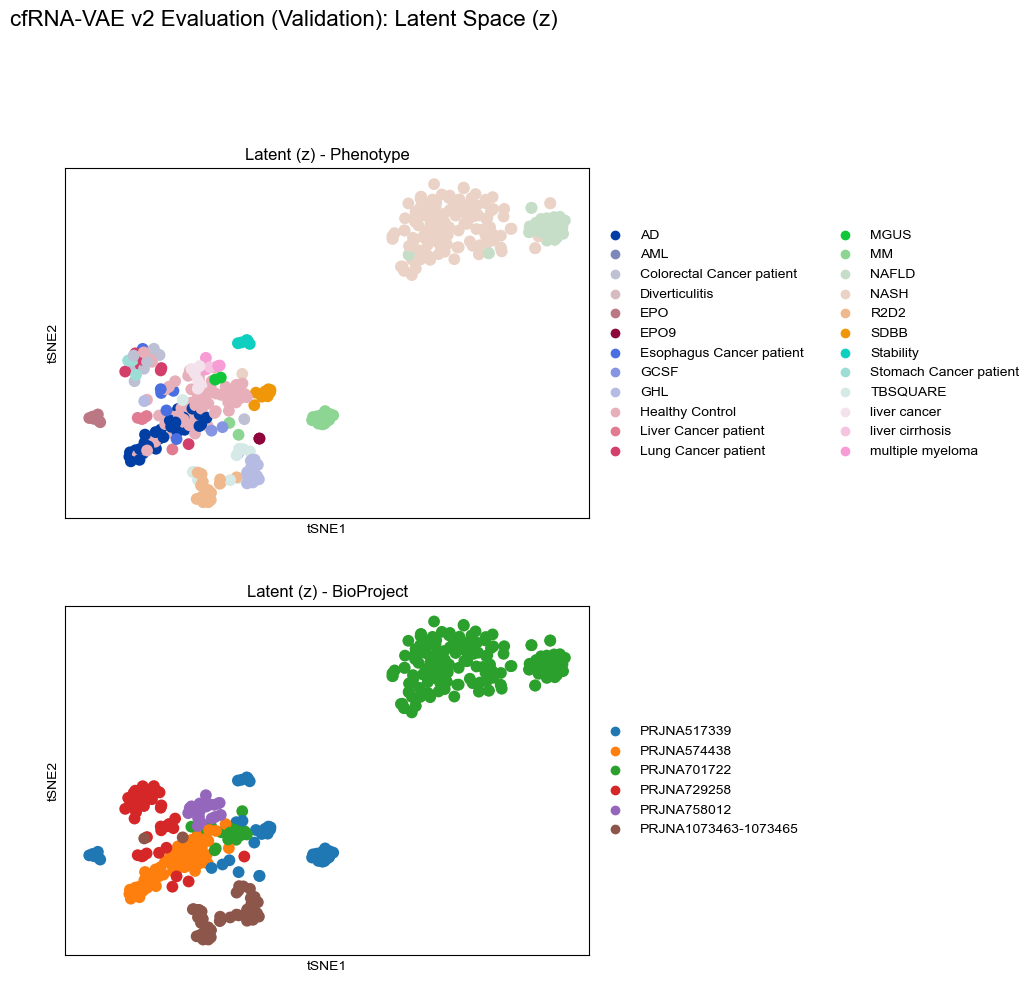

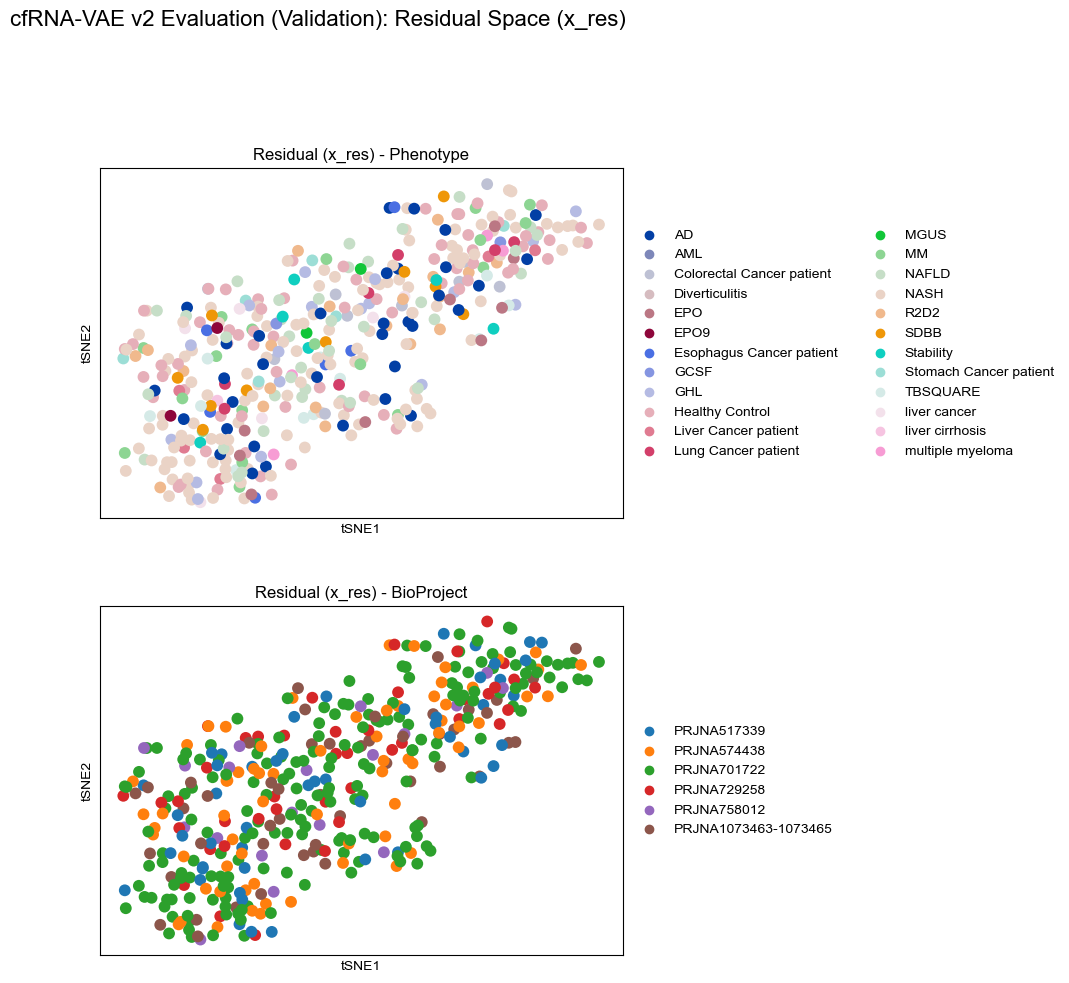

Extracting:   0%|          | 0/13 [00:00<?, ?it/s]

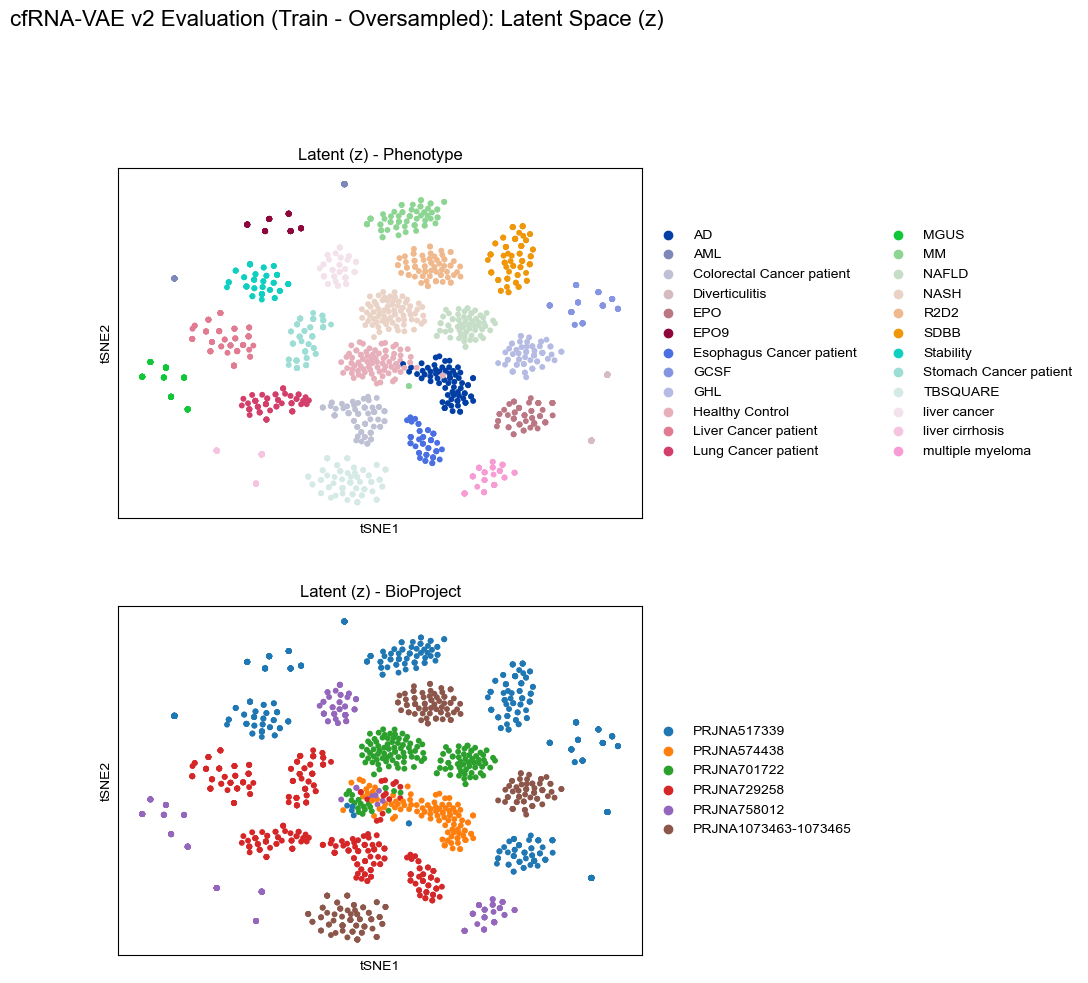

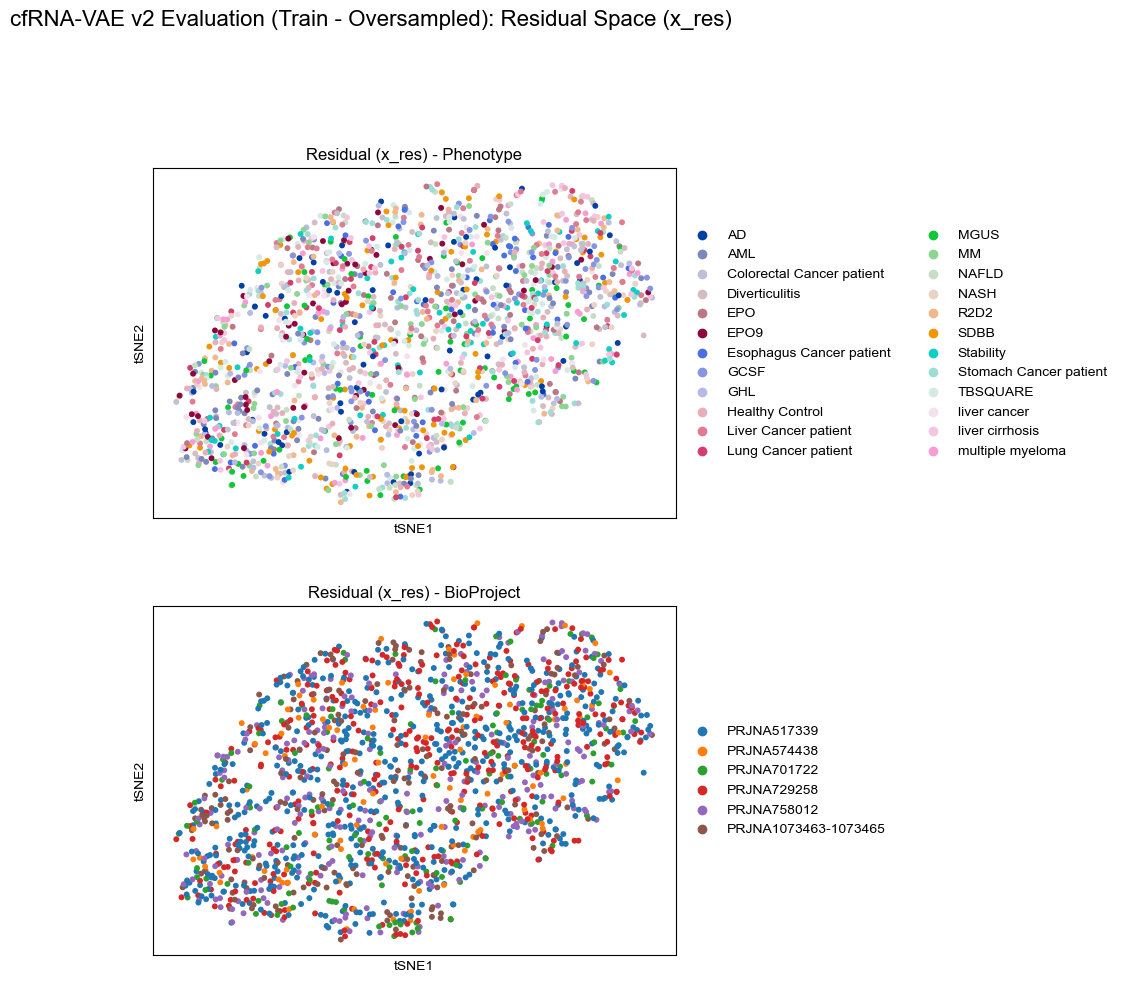

In [233]:
import scanpy as sc
import matplotlib.pyplot as plt

def visualize_latent_distribution(trainer, loader, class_names, title="VAE Latent Analysis"):
    res = trainer.get_outputs(loader)
    
    if hasattr(loader.dataset, 'obs_info'):
        matched_obs = loader.dataset.obs_info.iloc[res['indices']].reset_index(drop=True)
    else:
        matched_obs = pd.DataFrame({
            'Phenotype': [class_names[int(i)] for i in res['y']]
        })

    adata = sc.AnnData(X=res['x_res'], obs=matched_obs)
    adata.obsm['X_vae'] = res['z']
    
    color_cols = ['Phenotype', 'BioProject']
    color_cols = [c for c in color_cols if c in adata.obs.columns]
    
    adata_z = sc.AnnData(X=adata.obsm['X_vae'], obs=adata.obs)
    sc.pp.neighbors(adata_z, use_rep='X', n_neighbors=15)
    sc.tl.tsne(adata_z)
    
    fig_z = sc.pl.tsne(adata_z, color=color_cols, ncols=1,
                       title=[f"Latent (z) - {c}" for c in color_cols],
                       show=False, return_fig=True, )
    fig_z.suptitle(f"{title}: Latent Space (z)", fontsize=16, y=1.05)

    sc.pp.pca(adata, n_comps=min(50, adata.n_vars))
    sc.pp.neighbors(adata, use_rep='X_pca')
    sc.tl.tsne(adata)
    
    fig_res = sc.pl.tsne(adata, color=color_cols, ncols=1,
                         title=[f"Residual (x_res) - {c}" for c in color_cols],
                         show=False, return_fig=True)
    fig_res.suptitle(f"{title}: Residual Space (x_res)", fontsize=16, y=1.05)
    
    plt.show()
    return adata, adata_z

# Validation 데이터 시각화
adata_res_val, adata_z_val = visualize_latent_distribution(
    trainer, 
    val_loader, 
    class_names=cat_labels,
    title="cfRNA-VAE v2 Evaluation (Validation)"
)

# Train 데이터 시각화 (업샘플링된 분포 확인)
adata_res_train, adata_z_train = visualize_latent_distribution(
    trainer, 
    train_loader, 
    class_names=cat_labels,
    title="cfRNA-VAE v2 Evaluation (Train - Oversampled)"
)